In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("loan_data.csv")
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [3]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [4]:
df.info

<bound method DataFrame.info of        person_age person_gender person_education  person_income  \
0            22.0        female           Master        71948.0   
1            21.0        female      High School        12282.0   
2            25.0        female      High School        12438.0   
3            23.0        female         Bachelor        79753.0   
4            24.0          male           Master        66135.0   
...           ...           ...              ...            ...   
44995        27.0          male        Associate        47971.0   
44996        37.0        female        Associate        65800.0   
44997        33.0          male        Associate        56942.0   
44998        29.0          male         Bachelor        33164.0   
44999        24.0          male      High School        51609.0   

       person_emp_exp person_home_ownership  loan_amnt        loan_intent  \
0                   0                  RENT    35000.0           PERSONAL   
1        

In [5]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


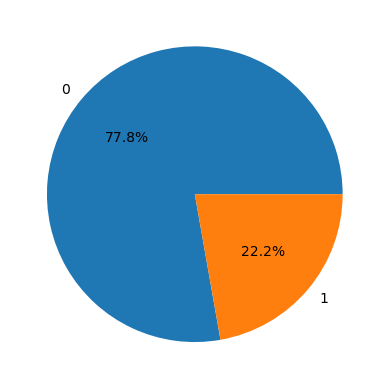

In [6]:
df['loan_status'].value_counts().plot.pie(autopct='%1.1f%%')
plt.ylabel('')
plt.show()

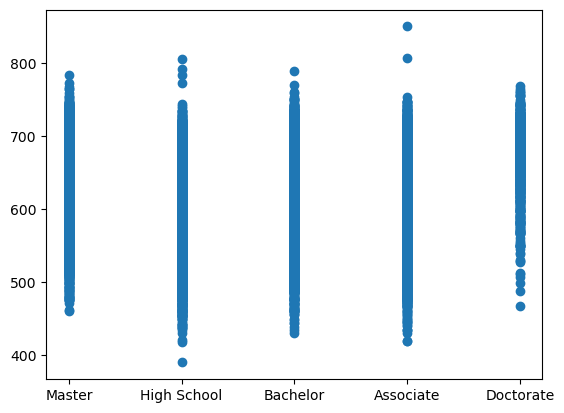

In [7]:
plt.scatter(df['person_education'],df['credit_score'])

In [8]:
#import library  
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,pair_confusion_matrix,confusion_matrix,classification_report
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
ohe=OneHotEncoder()
le_education=LabelEncoder()
le_home=LabelEncoder()
le_intent=LabelEncoder()
le_default=LabelEncoder()

In [9]:
df.drop(['person_gender','person_emp_exp','cb_person_cred_hist_length'],axis=1,inplace=True)


In [10]:
df.head()

,person_age,person_education,person_income,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,Master,71948.0,RENT,35000.0,PERSONAL,16.02,0.49,561,No,1
1,21.0,High School,12282.0,OWN,1000.0,EDUCATION,11.14,0.08,504,Yes,0
2,25.0,High School,12438.0,MORTGAGE,5500.0,MEDICAL,12.87,0.44,635,No,1
3,23.0,Bachelor,79753.0,RENT,35000.0,MEDICAL,15.23,0.44,675,No,1
4,24.0,Master,66135.0,RENT,35000.0,MEDICAL,14.27,0.53,586,No,1


In [11]:
df['loan_intent'].unique()

array(['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT',
       'DEBTCONSOLIDATION'], dtype=object)

In [12]:
df['person_home_ownership'].unique()

array(['RENT', 'OWN', 'MORTGAGE', 'OTHER'], dtype=object)

In [13]:
df['previous_loan_defaults_on_file']=np.where(df['previous_loan_defaults_on_file'].str.contains('No'),0,1)

In [14]:
# df['loan_intent']=le_intent.fit_transform(df['loan_intent'])
# df['person_home_ownership']=le_home.fit_transform(df['person_home_ownership'])  
# df['person_education']=le_education.fit_transform(df['person_education'])
df['person_education']=df['person_education'].replace({
    "High School":0,
    "Associate":1,
    "Bachelor":2,
    "Master":3,
    "Doctorate":4
})
df['person_home_ownership']=df['person_home_ownership'].replace({
    "RENT":0,
    "OWN":1,
    "MORTGAGE":2,
    "OTHER":3
})
df['loan_intent']=df['loan_intent'].replace({
    "PERSONAL":0,
    "EDUCATION":1,
    "MEDICAL":2,
    "VENTURE":3,
    "HOMEIMPROVEMENT":4,
    "DEBTCONSOLIDATION":5
})

C:\Users\avnin\AppData\Local\Temp\ipykernel_5772\1153850988.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['person_education']=df['person_education'].replace({
C:\Users\avnin\AppData\Local\Temp\ipykernel_5772\1153850988.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['person_home_ownership']=df['person_home_ownership'].replace({
C:\Users\avnin\AppData\Local\Temp\ipykernel_5772\1153850988.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old 

In [15]:
df.tail(15)

,person_age,person_education,person_income,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,credit_score,previous_loan_defaults_on_file,loan_status
44985,36.0,1,61015.0,0,18000.0,0,13.80,0.30,718,0,1
44986,34.0,2,41876.0,0,19594.0,5,12.03,0.47,707,0,1
44987,34.0,3,69210.0,0,2616.0,5,6.33,0.04,662,0,1
44988,28.0,1,49170.0,0,10401.0,4,11.97,0.21,677,0,1
44989,24.0,2,16779.0,0,4000.0,0,14.29,0.24,624,0,1
44990,31.0,3,136832.0,0,12319.0,0,16.92,0.09,722,0,1
44991,24.0,0,37786.0,2,13500.0,1,13.43,0.36,612,0,1
44992,23.0,2,40925.0,0,9000.0,0,11.01,0.22,487,0,1
44993,27.0,0,35512.0,0,5000.0,0,15.83,0.14,505,0,1
44994,24.0,1,31924.0,0,12229.0,2,10.70,0.38,678,0,1


<Axes: >

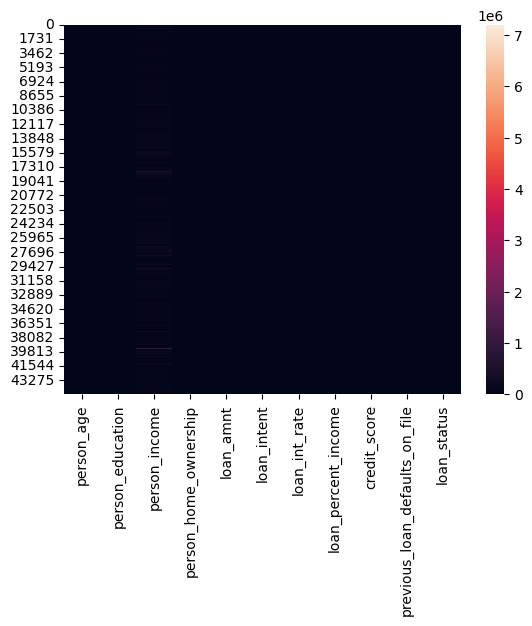

In [16]:
sns.heatmap(df)

In [17]:
x=df.drop("loan_status",axis=1)
y=df[['loan_status']]

In [18]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [19]:
from sklearn.naive_bayes import GaussianNB
gb=GaussianNB()
gb.fit(x_train,y_train)

c:\Users\avnin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GaussianNB()

In [20]:
y_pred=gb.predict(x_test)
print(confusion_matrix(y_pred,y_test))
print(accuracy_score(y_pred,y_test))
print(classification_report(y_pred,y_test))

[[8386 1817]
 [ 344  703]]
0.8079111111111111
              precision    recall  f1-score   support

           0       0.96      0.82      0.89     10203
           1       0.28      0.67      0.39      1047

    accuracy                           0.81     11250
   macro avg       0.62      0.75      0.64     11250
weighted avg       0.90      0.81      0.84     11250



In [21]:
df.columns

Index(['person_age', 'person_education', 'person_income',
       'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate',
       'loan_percent_income', 'credit_score', 'previous_loan_defaults_on_file',
       'loan_status'],
      dtype='object')

In [26]:
import joblib
joblib.dump(gb,"gb_trained.pkl")

['gb_trained.pkl']

In [23]:
import joblib
joblib.dump(le_intent,'le_intent.pkl')
joblib.dump(le_home,'le_home.pkl')
joblib.dump(le_education,'le_education.pkl')

['le_education.pkl']

In [24]:
print(le_intent.classes_)

['DEBTCONSOLIDATION' 'EDUCATION' 'HOMEIMPROVEMENT' 'MEDICAL' 'PERSONAL'
 'VENTURE']


In [22]:
print(gb.classes_)

[0 1]


In [26]:
print(y.value_counts())

loan_status
0              35000
1              10000
Name: count, dtype: int64


In [28]:
print(df['loan_status'].value_counts())

loan_status
0    35000
1    10000
Name: count, dtype: int64
